# Team 22 (Introduction to Artificial Intelligence)



This project utilizes the Enron Email Dataset, a widely recognized collection of over 500,000 real-world emails from the Enron Corporation. The dataset, accessible at [Enron Email Dataset](https://www.cs.cmu.edu/~enron/), serves as a valuable resource for testing and evaluating machine learning and natural language processing (NLP) models. Its diversity and scale make it ideal for tackling challenges such as handling noise, ambiguity, and large volumes of textual data.

In this notebook, we implement and evaluate various machine learning models to classify emails into meaningful categories, demonstrating their effectiveness in automating email management and enhancing organizational efficiency.


## Cleaning script used for preprocessing the dataset

The script below was used by the team to clean the dataset.

In [8]:
import os
import csv
import re

# Function to clean the email body by removing common footer patterns
def remove_footer(email_body):
    footer_patterns = [
        r"(?i)(best regards|sincerely|kind regards|thanks|regards|cheers|thank you)[\s\S]+",
        r"(?i)(unsubscribe|opt-out|email preferences|privacy policy)[\s\S]+",
        r"(?i)(contact details|company information)[\s\S]+",
        r"(?i)(confidentiality notice)[\s\S]+",
    ]
    for pattern in footer_patterns:
        email_body = re.sub(pattern, "", email_body)
    return email_body.strip()

# Function to read the raw email file and extract relevant fields
def extract_email_fields(file_path):
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as file:
        email_content = file.read()

    date, sender, recipient, subject, body = None, None, None, None, None
    lines = email_content.split("\n")
    for line in lines:
        if line.lower().startswith("date:"):
            date = line[len("Date:"):].strip()
        elif line.lower().startswith("from:"):
            sender = line[len("From:"):].strip()
        elif line.lower().startswith("to:"):
            recipient = line[len("To:"):].strip()
        elif line.lower().startswith("subject:"):
            subject = line[len("Subject:"):].strip()

    try:
        body_start = email_content.index("\n\n")
        body = email_content[body_start:].strip()
    except ValueError:
        body = ""

    body_cleaned = remove_footer(body)

    return {
        "Date": date,
        "From": sender,
        "To": recipient,
        "Subject": subject,
        "Message": body_cleaned
    }

# Function to ensure that the directory for the CSV file exists
def ensure_directory_exists(directory_path):
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)

# Function to save data to a CSV file
def save_to_csv(data, csv_file_path):
    ensure_directory_exists(os.path.dirname(csv_file_path))
    if not data:
        print("No email data to save.")
        return
    with open(csv_file_path, mode="w", newline="", encoding="utf-8") as csv_file:
        writer = csv.DictWriter(csv_file, fieldnames=["Date", "From", "To", "Subject", "Message"])
        writer.writeheader()
        writer.writerows(data)

# Function to process multiple email files from a directory
def process_emails_from_directory(directory_path, output_directory, max_files=50):
    # Get a list of all files in the directory
    email_files = [os.path.join(directory_path, file) for file in os.listdir(directory_path) if os.path.isfile(os.path.join(directory_path, file))]
    
    num_files = min(len(email_files), max_files)  # Process up to max_files or all files if fewer
    for idx, file_path in enumerate(email_files[:num_files]):
        try:
            email_data = extract_email_fields(file_path)
            csv_file_name = f"{idx + 1}.csv"
            csv_file_path = os.path.join(output_directory, csv_file_name)
            save_to_csv([email_data], csv_file_path)
            #print(f"Cleaned email {idx + 1} saved to {csv_file_path}")
        except Exception as e:
            print(f"Error processing file {file_path}: {e}")

# Directory containing email files (replace with the actual directory path)
email_directory_path = r"maildir/zufferli-j/inbox"

# Output directory for cleaned emails
output_directory = r"cleaned_emails/zufferli-j"

# Process emails from the directory
process_emails_from_directory(email_directory_path, output_directory)

## Loading Directories


In [17]:
import os

# loading the directories to be used in the project
current_dir = os.getcwd()  # Current directory 
cleaned_emails_path = os.path.join(current_dir, "cleaned_emails_nn")  # The dataset after preprocessing
test_dir = os.path.join(cleaned_emails_path, "test_emails")  # Test files for testing

# Debugging To check files
if not os.path.exists(cleaned_emails_path):
    print(f"Path does not exist: {cleaned_emails_path}")
else:
    print(f"Path exists: {cleaned_emails_path}")
    print("Contents of the cleaned_emails_nn folder:")
    print(os.listdir(cleaned_emails_path))

if not os.path.exists(test_dir):
    print(f"Test directory does not exist: {test_dir}")
else:
    print(f"Test directory exists: {test_dir}")
    print("Contents of the test_emails folder:")
    print(os.listdir(test_dir))

Path exists: d:\Team22_Intro_To_AI\cleaned_emails_nn
Contents of the cleaned_emails_nn folder:
['.DS_Store', 'beck-s', 'benson-r', 'brawner-s', 'buy-r', 'campbell-l', 'carson-m', 'causholli-m', 'corman-s', 'crandell-s', 'cuilla-m', 'dasovich-j', 'davis-d', 'dean-c', 'derrick-j', 'donoho-l', 'donohoe-t', 'ermis-f', 'farmer-d', 'forney-j', 'gang-l', 'geaccone-t', 'gilbertsmith-d', 'grigsby-m', 'haedicke-m', 'harris-s', 'heard-m', 'hendrickson-s', 'hernandez-j', 'hodge-j', 'holst-k', 'horton-s', 'hyatt-k', 'kaminski-v', 'keavey-p', 'keiser-k', 'kitchen-l', 'kuykendall-t', 'lavorato-j', 'lay-k', 'lenhart-m', 'lokay-m', 'lokey-t', 'lucci-p', 'maggi-m', 'martin-t', 'may-l', 'mcconnell-m', 'mckay-b', 'mclaughlin-e', 'meyers-a', 'mims-thurston-p', 'motley-m', 'neal-s', 'nemec-g', 'parks-j', 'perlingiere-d', 'phanis-s', 'pimenov-v', 'platter-p', 'presto-k', 'quigley-d', 'rapp-b', 'richey-c', 'ring-a', 'rogers-b', 'ruscitti-k', 'sager-e', 'saibi-e', 'sanchez-m', 'scholtes-d', 'schoolcraft-d', 's

## Neural Network Classification

We begins by loading email data from multiple folders, excluding the test file folder, which is reserved for testing. The emails are read from text files and stored in two separate lists: one for training data and another for testing data. These lists are then converted into `pandas` DataFrames, each containing the email text and a default label. The dataset is now ready for feature extraction, model training, and evaluation.

In [18]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay , precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
import random

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Ensure Deterministic Operations in TensorFlow
#Tensor flow throws a small headsup "I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
#2024-12-22 11:54:02.176989: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`."
#os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

email_data = []

# We Load all emails except for the test file
all_folders = [
    folder for folder in os.listdir(cleaned_emails_path)
    if folder != "test-emails" and not folder.startswith(".")  # Exclude hidden files like `.DS_Store`, as some of our cleaning was don in macOS so the file was created
]
for folder in all_folders:
    folder_path = os.path.join(cleaned_emails_path, folder)
    if os.path.isdir(folder_path):  # Ensure it's a directory
        for file_name in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file_name)
            if os.path.isfile(file_path):  # Ensure it's a file
                try:
                    with open(file_path, 'r', encoding='latin-1') as f:
                        content = f.read()
                        email_data.append([content, 0])  # Default label
                except Exception as e:
                    print(f"Could not read {file_name}: {e}")

# Load test emails for testing
test_data = []
test_data = []

def load_emails_from_folder(folder_path):
    for root, dirs, files in os.walk(folder_path):  
        for file_name in files:
            file_path = os.path.join(root, file_name)
            if os.path.isfile(file_path):  # Ensure it's a file
                try:
                    with open(file_path, 'r', encoding='latin-1') as f:
                        content = f.read()
                        test_data.append([content, 0])  # Default label for testing
                except Exception as e:
                    print(f"Could not read {file_name}: {e}")

# Load emails from the test directory (including subfolders)
load_emails_from_folder(test_dir)

# Step 2: Create DataFrames
train_df = pd.DataFrame(email_data, columns=['email_text', 'label'])
test_df = pd.DataFrame(test_data, columns=['email_text', 'label'])


### Step 3: Assign Labels Using Keywords
In next step, we classify the emails into two categories: spam (label 1) and not spam (label 0). We define a list of `spam_keywords`, which includes common words or phrases often associated with spam emails, such as "win", "free", and "prize". The code then assigns a label to each email based on whether any of these keywords appear in the email text.

- If an email contains one of the keywords, it is labeled as spam (1).
- Otherwise, it is labeled as non-spam (0).

Finally, the distribution of labels in both the training and testing datasets is printed to give an overview of the class balance.

In [19]:
# Step 3: We Assign Labels Using Keywords, most important part of our classification
#The words were buzz words seen in most of the spam emails
spam_keywords = [
    'win', 'prize', 'free', 'cash', 'exclusive', 'lucky', 'lottery', 'selected', 'reward', 'won',
    'iwon', 'jackpot', 'buy', 'coupon', 'discount', 'romantic', 'www.match.com',
    'gifts', 'enter to win', 'complete a short survey', 'hotwebcash', 'sending spam', '100% approved',
    'no credit check', 'no late charges', 'apply here', 'eligible singles for you'
]
train_df['label'] = train_df['email_text'].apply(lambda x: 1 if any(word in x.lower() for word in spam_keywords) else 0)
test_df['label'] = test_df['email_text'].apply(lambda x: 1 if any(word in x.lower() for word in spam_keywords) else 0)

print("\nTraining Class Distribution:")
print(train_df['label'].value_counts())

print("\nTesting Class Distribution:")
print(test_df['label'].value_counts())



Training Class Distribution:
label
0    3041
1    1801
Name: count, dtype: int64

Testing Class Distribution:
label
0    1128
1     644
Name: count, dtype: int64


### Step 4: Feature Extraction

In this step, we use the **TF-IDF Vectorizer** to convert the raw email text into numerical features. The `TfidfVectorizer` captures the importance of words in each email, ignoring common words (stop words) like "the" and "is". We limit the number of features to the top 3000 words in the dataset. After transformation, we separate the features (`X_train` and `X_test`) and labels (`y_train` and `y_test`) for both training and testing datasets.

### Step 5: Handle Class Imbalance Using SMOTE

To tackle the issue of class imbalance (where spam emails may be underrepresented), we apply **SMOTE (Synthetic Minority Over-sampling Technique)**. SMOTE generates synthetic examples of the minority class (spam), balancing the class distribution in the training set. This ensures the model doesn't bias towards the majority class (non-spam).

### Step 6: Neural Network Model with TensorFlow

We build a **Neural Network** model using **TensorFlow** for binary classification (spam vs. non-spam). The model consists of:
- **Input layer**: Accepts the features of the emails.
- **Two hidden layers**: The first with 64 neurons and the second with 32, both using the ReLU activation function. Dropout (0.4) is added to both layers to prevent overfitting.
- **Output layer**: A single neuron with a sigmoid activation function to output a probability between 0 and 1, classifying the email as spam or non-spam.

The model is compiled with the **Adam optimizer**, **binary cross-entropy loss**, and **accuracy** as the evaluation metric, which is suitable for binary classification tasks like in ours.


In [22]:
# Step 4: Feature Extraction
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
X_train = vectorizer.fit_transform(train_df['email_text']).toarray()
y_train = train_df['label']
X_test = vectorizer.transform(test_df['email_text']).toarray()
y_test = test_df['label']

# Step 5: Handle Class Imbalance Using SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Step 6: Neural Network Model with TensorFlow
model = Sequential([
    Input(shape=(X_train_resampled.shape[1],)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.4),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

### Step 7: Train the Neural Network

In this step, we train the neural network using the training data (`X_train_resampled` and `y_train_resampled`). We specify the following parameters:

- **`epochs=100`**: The model will go through the entire training dataset 20 times.
- **`batch_size=32`**: The training data is divided into smaller batches (groups of 32 samples). 
- **`validation_split=0.2`**: 20% of the training data will be set aside as a validation set.

By training the model over these epochs, we allow it to learn the patterns in the data and adjust its parameters (weights) to minimize the error (loss) in predicting whether an email is spam or not.


In [25]:
#Train the Neural Network
history = model.fit(
    X_train_resampled, y_train_resampled, 
    epochs=100, batch_size=32, 
    validation_split=0.2, verbose=2,
)




Epoch 1/100
153/153 - 1s - 7ms/step - accuracy: 0.9455 - loss: 0.3579 - val_accuracy: 0.9466 - val_loss: 0.3773
Epoch 2/100
153/153 - 1s - 8ms/step - accuracy: 0.9507 - loss: 0.3588 - val_accuracy: 0.9408 - val_loss: 0.3840
Epoch 3/100
153/153 - 1s - 8ms/step - accuracy: 0.9490 - loss: 0.3561 - val_accuracy: 0.9384 - val_loss: 0.3860
Epoch 4/100
153/153 - 1s - 8ms/step - accuracy: 0.9486 - loss: 0.3575 - val_accuracy: 0.9474 - val_loss: 0.3711
Epoch 5/100
153/153 - 1s - 7ms/step - accuracy: 0.9505 - loss: 0.3540 - val_accuracy: 0.9458 - val_loss: 0.3765
Epoch 6/100
153/153 - 1s - 7ms/step - accuracy: 0.9490 - loss: 0.3539 - val_accuracy: 0.9458 - val_loss: 0.3727
Epoch 7/100
153/153 - 1s - 8ms/step - accuracy: 0.9511 - loss: 0.3521 - val_accuracy: 0.9417 - val_loss: 0.3753
Epoch 8/100
153/153 - 1s - 7ms/step - accuracy: 0.9498 - loss: 0.3507 - val_accuracy: 0.9466 - val_loss: 0.3696
Epoch 9/100
153/153 - 1s - 7ms/step - accuracy: 0.9511 - loss: 0.3511 - val_accuracy: 0.9458 - val_loss:

Lets try to change some Hyperparameters 
- The learning rate seems to be very high, lets try to decrase it and also add early stopping, for the training to stop if the val_accuracy stops imroving.

In [ ]:


# Step 6: Neural Network Model with TensorFlow
model2 = Sequential([
    Input(shape=(X_train_resampled.shape[1],)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.4),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

model2.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Train the Neural Network
early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
history = model2.fit(
    X_train_resampled, y_train_resampled, 
    epochs=100, batch_size=32, #11 is optimal
    validation_split=0.2, verbose=2,
    callbacks=[early_stopping]
)



Epoch 1/100
153/153 - 4s - 25ms/step - accuracy: 0.6138 - loss: 1.8740 - val_accuracy: 0.0000e+00 - val_loss: 1.5609
Epoch 2/100
153/153 - 1s - 9ms/step - accuracy: 0.6249 - loss: 1.2822 - val_accuracy: 0.0000e+00 - val_loss: 1.2588
Epoch 3/100
153/153 - 1s - 9ms/step - accuracy: 0.6251 - loss: 1.0256 - val_accuracy: 0.0000e+00 - val_loss: 1.1394
Epoch 4/100
153/153 - 1s - 8ms/step - accuracy: 0.6251 - loss: 0.9052 - val_accuracy: 0.0000e+00 - val_loss: 1.0809
Epoch 5/100
153/153 - 1s - 9ms/step - accuracy: 0.6265 - loss: 0.8387 - val_accuracy: 0.0000e+00 - val_loss: 1.0466
Epoch 6/100
153/153 - 1s - 8ms/step - accuracy: 0.6321 - loss: 0.7928 - val_accuracy: 0.0049 - val_loss: 1.0178
Epoch 7/100
153/153 - 1s - 7ms/step - accuracy: 0.6419 - loss: 0.7573 - val_accuracy: 0.0879 - val_loss: 0.9952
Epoch 8/100
153/153 - 1s - 8ms/step - accuracy: 0.6664 - loss: 0.7279 - val_accuracy: 0.1882 - val_loss: 0.9686
Epoch 9/100
153/153 - 1s - 7ms/step - accuracy: 0.6960 - loss: 0.7036 - val_accurac

In the above the training accuracy is higher than validation accuracy, so the model is has not yet generalized yet. So lets increase the patience on the early stopping.

In [31]:
model3 = Sequential([
    Input(shape=(X_train_resampled.shape[1],)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.4),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

model3.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Train the Neural Network
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model3.fit(
    X_train_resampled, y_train_resampled, 
    epochs=100, batch_size=32, #11 is optimal
    validation_split=0.2, verbose=2,
    callbacks=[early_stopping]
)


Epoch 1/100
153/153 - 4s - 23ms/step - accuracy: 0.6043 - loss: 1.8727 - val_accuracy: 0.0000e+00 - val_loss: 1.5454
Epoch 2/100
153/153 - 1s - 7ms/step - accuracy: 0.6251 - loss: 1.2785 - val_accuracy: 0.0000e+00 - val_loss: 1.2347
Epoch 3/100
153/153 - 1s - 6ms/step - accuracy: 0.6253 - loss: 1.0221 - val_accuracy: 0.0000e+00 - val_loss: 1.1087
Epoch 4/100
153/153 - 1s - 8ms/step - accuracy: 0.6284 - loss: 0.9026 - val_accuracy: 0.0000e+00 - val_loss: 1.0439
Epoch 5/100
153/153 - 1s - 7ms/step - accuracy: 0.6366 - loss: 0.8344 - val_accuracy: 0.0222 - val_loss: 1.0158
Epoch 6/100
153/153 - 1s - 6ms/step - accuracy: 0.6499 - loss: 0.7883 - val_accuracy: 0.0879 - val_loss: 0.9894
Epoch 7/100
153/153 - 1s - 6ms/step - accuracy: 0.6697 - loss: 0.7524 - val_accuracy: 0.1816 - val_loss: 0.9644
Epoch 8/100
153/153 - 1s - 7ms/step - accuracy: 0.6931 - loss: 0.7224 - val_accuracy: 0.2531 - val_loss: 0.9417
Epoch 9/100
153/153 - 1s - 6ms/step - accuracy: 0.7237 - loss: 0.6997 - val_accuracy: 0

Now its better as the training accuracy and validation accuracy has increased and closer.
It also appears that validation loss is steadily decreasing, and validation accuracy is improving (with small fluctuations), so lets increase the patience a bit more and the epochs

In [34]:
model4 = Sequential([
    Input(shape=(X_train_resampled.shape[1],)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.4),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

model4.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Train the Neural Network
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model4.fit(
    X_train_resampled, y_train_resampled, 
    epochs=200, batch_size=32, 
    validation_split=0.2, verbose=2,
    callbacks=[early_stopping]
)

Epoch 1/200
153/153 - 4s - 29ms/step - accuracy: 0.5544 - loss: 1.8610 - val_accuracy: 0.0000e+00 - val_loss: 1.5105
Epoch 2/200
153/153 - 1s - 8ms/step - accuracy: 0.6257 - loss: 1.2676 - val_accuracy: 0.0000e+00 - val_loss: 1.1807
Epoch 3/200
153/153 - 1s - 9ms/step - accuracy: 0.6253 - loss: 1.0153 - val_accuracy: 0.0000e+00 - val_loss: 1.0536
Epoch 4/200
153/153 - 1s - 8ms/step - accuracy: 0.6255 - loss: 0.9005 - val_accuracy: 0.0000e+00 - val_loss: 1.0019
Epoch 5/200
153/153 - 1s - 9ms/step - accuracy: 0.6282 - loss: 0.8386 - val_accuracy: 0.0000e+00 - val_loss: 0.9791
Epoch 6/200
153/153 - 1s - 9ms/step - accuracy: 0.6306 - loss: 0.7973 - val_accuracy: 0.0000e+00 - val_loss: 0.9651
Epoch 7/200
153/153 - 2s - 11ms/step - accuracy: 0.6411 - loss: 0.7648 - val_accuracy: 0.0362 - val_loss: 0.9457
Epoch 8/200
153/153 - 1s - 8ms/step - accuracy: 0.6625 - loss: 0.7373 - val_accuracy: 0.1389 - val_loss: 0.9241
Epoch 9/200
153/153 - 1s - 8ms/step - accuracy: 0.6900 - loss: 0.7140 - val_ac

### Model Training Summary

**Performance Over Epochs:**
- **Training Accuracy:** Improved steadily, reaching ~96% (0.9601) by epoch 200.
- **Validation Accuracy:** Increased consistently, reaching ~96.47% (0.9647) by epoch 200.
- **Training Loss:** Decreased over time, stabilizing around 0.3184.
- **Validation Loss:** Also decreased, stabilizing at ~0.3176 by the end.

**Key Observations:**
- **Stability:** Both training and validation accuracy showed consistent improvement, with minimal fluctuations and a small gap, indicating good generalization.
- **Loss Reduction:** Training and validation losses steadily decreased, suggesting effective learning.
- **Patience Impact:** Increased patience helped prevent premature stopping, allowing for more fine-tuning and better results.

**Conclusion:**
The model demonstrated promising results with strong accuracy and low loss. Increasing patience and epochs helped avoid overfitting and facilitated deeper learning.

Now we can move on to testing



### Model Evaluation on Test Data

In this section, we evaluate the performance of the trained model i.e thebest model yet **model4** on the test data using accuracy and confusion matrices.



56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Neural Network Accuracy on Test Data: 0.87

Confusion Matrix (Raw Numbers):
[[1052   76]
 [ 152  492]]


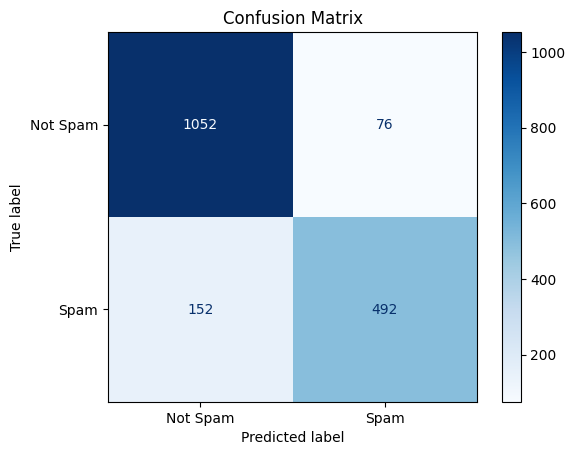


Normalized Confusion Matrix (Proportions):
[[0.93 0.07]
 [0.24 0.76]]


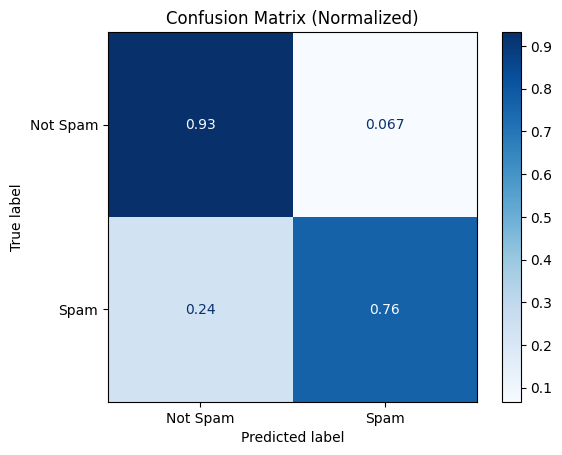

In [35]:
# Evaluate on Test Data
y_pred = (model4.predict(X_test) > 0.5).astype(int).flatten()
accuracy = accuracy_score(y_test, y_pred)
print("\nNeural Network Accuracy on Test Data: %.2f" % accuracy)

# Step 7: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (Raw Numbers):")
print(cm)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Spam", "Spam"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
np.set_printoptions(precision=2)
print("\nNormalized Confusion Matrix (Proportions):")
print(cm_normalized)

# Plot Normalized Confusion Matrix
disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=["Not Spam", "Spam"])
disp_normalized.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Normalized)")
plt.show()



1. **Accuracy on Test Data**: The model achieved an accuracy of 87% on the test data, indicating that it correctly classified 87% of the instances.

2. **Confusion Matrix (Raw Numbers)**: The raw confusion matrix shows the following:
   - **True Negatives (Not Spam correctly classified)**: 1052
   - **False Positives (Not Spam incorrectly classified as Spam)**: 76
   - **False Negatives (Spam incorrectly classified as Not Spam)**: 152
   - **True Positives (Spam correctly classified)**: 492

3. **Normalized Confusion Matrix**: The normalized confusion matrix, showing proportions for each class, is as follows:
   - **Not Spam**: 93% correctly classified (True Negative rate), with 7% misclassified as Spam (False Positive rate).
   - **Spam**: 76% correctly classified (True Positive rate), with 24% misclassified as Not Spam (False Negative rate).


These results highlight that the model performs well in classifying "Not Spam" but has a higher rate of false negatives for "Spam".

### K-Fold Cross-Validation Results

In this section, we perform **K-Fold Cross-Validation** with 5 splits to evaluate the performance of the model on different subsets of the training data. 


In [36]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
print("\nK-Fold Results:")

# Initialize lists to store metrics
accuracies = []
precisions = []
recalls = []
f1_scores = []

# Perform K-Fold Cross-Validation
for train_index, validate_index in kf.split(X_train_resampled, y_train_resampled):
    # Split the data into training and validation sets
    X_train_fold = X_train_resampled[train_index]
    X_validate_fold = X_train_resampled[validate_index]
    y_train_fold = y_train_resampled[train_index]
    y_validate_fold = y_train_resampled[validate_index]

    # Reinitialize the model for each fold
    model4 = Sequential([
    Input(shape=(X_train_resampled.shape[1],)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.4),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])


    model4.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model
    model4.fit(
        X_train_fold, y_train_fold,
        epochs=200, batch_size=32, verbose=0
    )

    # Validate the model
    y_pred_fold = (model.predict(X_validate_fold) > 0.5).astype(int).flatten()

    # Calculate Precision, Recall, and F1-Score for the current fold
    precision = precision_score(y_validate_fold, y_pred_fold)
    recall = recall_score(y_validate_fold, y_pred_fold)
    f1 = f1_score(y_validate_fold, y_pred_fold)
    fold_accuracy = accuracy_score(y_validate_fold, y_pred_fold)

    # Append results to lists for calculating mean and std
    accuracies.append(fold_accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    
    # Print the results for the current fold
    print(f"Fold #{fold}, Accuracy: {fold_accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-Score: {f1:.2f}")
    fold += 1

# Calculate and print the mean and standard deviation across all folds
print("\nK-Fold Cross-Validation Average Metrics:")
print(f"Average Accuracy: {np.mean(accuracies):.2f} ± {np.std(accuracies):.2f}")
print(f"Average Precision: {np.mean(precisions):.2f} ± {np.std(precisions):.2f}")
print(f"Average Recall: {np.mean(recalls):.2f} ± {np.std(recalls):.2f}")
print(f"Average F1-Score: {np.mean(f1_scores):.2f} ± {np.std(f1_scores):.2f}")


K-Fold Results:
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Fold #1, Accuracy: 0.98
Precision: 1.00
Recall: 0.97
F1-Score: 0.98
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Fold #2, Accuracy: 0.98
Precision: 1.00
Recall: 0.96
F1-Score: 0.98
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Fold #3, Accuracy: 0.98
Precision: 1.00
Recall: 0.97
F1-Score: 0.98
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Fold #4, Accuracy: 0.98
Precision: 1.00
Recall: 0.97
F1-Score: 0.98
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Fold #5, Accuracy: 0.99
Precision: 1.00
Recall: 0.97
F1-Score: 0.99

K-Fold Cross-Validation Average Metrics:
Average Accuracy: 0.98 ± 0.00
Average Precision: 1.00 ± 0.00
Average Recall: 0.97 ± 0.01
Average F1-Score: 0.98 ± 0.00


# K-Fold Cross-Validation Results

We performed **K-Fold Cross-Validation** on the training dataset using **5 splits** to evaluate the model's performance more robustly. Below are the results:

## Fold-wise Results:
- **Fold #1**: 
  - Accuracy: 0.98
  - Precision: 1.00
  - Recall: 0.97
  - F1-Score: 0.98
- **Fold #2**: 
  - Accuracy: 0.98
  - Precision: 1.00
  - Recall: 0.96
  - F1-Score: 0.98
- **Fold #3**: 
  - Accuracy: 0.98
  - Precision: 1.00
  - Recall: 0.97
  - F1-Score: 0.98
- **Fold #4**: 
  - Accuracy: 0.98
  - Precision: 1.00
  - Recall: 0.97
  - F1-Score: 0.98
- **Fold #5**: 
  - Accuracy: 0.99
  - Precision: 1.00
  - Recall: 0.97
  - F1-Score: 0.99

## Average Metrics Across All Folds:
- **Average Accuracy**: 0.98 ± 0.00
- **Average Precision**: 1.00 ± 0.00
- **Average Recall**: 0.97 ± 0.01
- **Average F1-Score**: 0.98 ± 0.00

## Key Observations:
- The model consistently performs at a **high accuracy** (98% on average) across all folds, indicating its ability to generalize well.
- **Precision** is perfect (**1.00**), meaning the model is excellent at avoiding false positives.
- **Recall** ranges between **96-97%**, ensuring the model is capturing most of the true positives, with a slight dip in Fold #2.
- The **F1-Score** is very close to **1.00** across all folds, demonstrating a good balance between precision and recall.

## Conclusion:
The model shows strong performance with high **precision**, **recall**, and **F1-scores** across all folds, making it highly reliable for classification tasks. The stability in the metrics across the different folds suggests good generalization, making the model robust for unseen data.
